In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [4]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df["Sleep Disorder"].value_counts()


Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [5]:
if "Person ID" in df.columns:
    df.drop(columns=["Person ID"], inplace=True)

df.head()


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [6]:
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})
df["BMI Category"].value_counts()


BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

In [7]:
if "Blood Pressure" in df.columns:
    df[["Systolic_BP", "Diastolic_BP"]] = (
        df["Blood Pressure"].astype(str).str.split("/", expand=True).astype(int)
    )
    df.drop(columns=["Blood Pressure"], inplace=True)

df.head()


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [8]:
X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

X.shape, y.shape


((374, 12), (374,))

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)


Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [10]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

categorical_cols, numerical_cols


(['Gender', 'Occupation', 'BMI Category'],
 ['Age',
  'Sleep Duration',
  'Quality of Sleep',
  'Physical Activity Level',
  'Stress Level',
  'Heart Rate',
  'Daily Steps',
  'Systolic_BP',
  'Diastolic_BP'])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train.shape, X_test.shape


((299, 12), (75, 12))

In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight=None,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="mlogloss",
    random_state=42
)


In [19]:
stack_clf = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=4000,C=2.0),
    stack_method="predict_proba",
    n_jobs=-1
)


In [22]:
stacking_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", stack_clf)
])

stacking_model


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
stacking_model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred = stacking_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"STACKING ACCURACY: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


STACKING ACCURACY: 96.00%

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75


Confusion Matrix:
 [[13  0  2]
 [ 0 44  0]
 [ 1  0 15]]


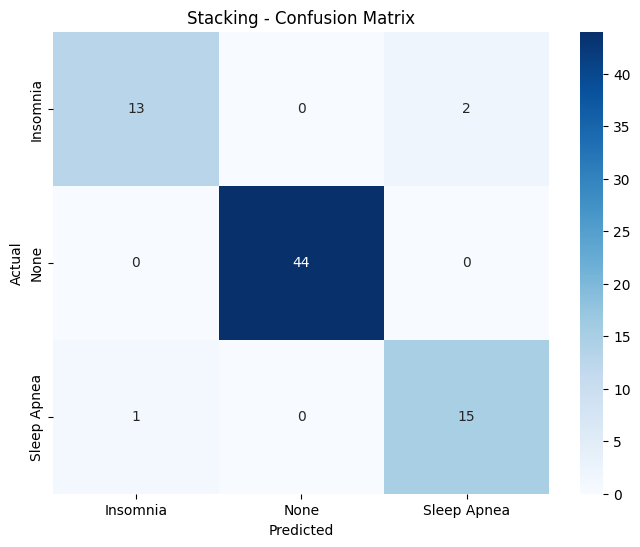

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking - Confusion Matrix")
plt.show()


In [18]:
from sklearn.metrics import f1_score
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


Macro F1: 0.9352142110762801


5 fold cv added 

In [27]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint, uniform


In [28]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack_clf = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=4000),
    stack_method="predict_proba",
    cv=cv5,          # ✅ important
    n_jobs=-1
)

stacking_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", stack_clf)
])


In [29]:
param_dist = {
    
    "classifier__rf__n_estimators": randint(200, 800),
    "classifier__rf__max_depth": [None, 6, 8, 10, 12, 15],
    "classifier__rf__min_samples_split": randint(2, 10),
    "classifier__rf__min_samples_leaf": randint(1, 6),
    "classifier__rf__max_features": ["sqrt", "log2", None],

    
    "classifier__xgb__n_estimators": randint(200, 900),
    "classifier__xgb__learning_rate": uniform(0.01, 0.09),   # ~ 0.01–0.10
    "classifier__xgb__max_depth": randint(3, 8),
    "classifier__xgb__subsample": uniform(0.7, 0.3),         # ~ 0.7–1.0
    "classifier__xgb__colsample_bytree": uniform(0.7, 0.3),  # ~ 0.7–1.0
    "classifier__xgb__min_child_weight": randint(1, 8),
    "classifier__xgb__gamma": uniform(0.0, 0.4),
    "classifier__xgb__reg_lambda": uniform(0.5, 2.0),

    #  Meta model
    "classifier__final_estimator__C": uniform(0.5, 4.0)       # LR regularization
}


In [ ]:
search = RandomizedSearchCV(
    estimator=stacking_model,
    param_distributions=param_dist,
    n_iter=40,                 
    scoring="accuracy",
    cv=cv5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best CV Accuracy:", search.best_score_)
print("Best Params:", search.best_params_)
best_model = search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
